The LeNet architecture was initially implemented using SGD as the optimizer and Sigmoid as the activation function. Preliminary results showed an accuracy of approximately 88%. To enhance model performance, I transitioned to the Adam optimizer and adopted ReLU as the activator. After several rounds of adjusting the learning rate and the number of epochs, the model successfully achieved a peak accuracy of 98.5%.

In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms   
import matplotlib.pyplot as plt 

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))#归一化
])

In [11]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_iter = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [12]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5,padding=2),  
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 池化层
            nn.Conv2d(6, 16, kernel_size=5),  
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2), # 池化层
            nn.Flatten(),  # 拉平
            nn.Linear(16 * 5 * 5, 120),  
            nn.ReLU(),
            nn.Linear(120, 84), 
            nn.ReLU(),
            nn.Linear(84, 10)  
        )

    def forward(self, x):
        return self.net(x)

In [13]:
def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

net = LeNet()
net.apply(init_weights)

LeNet(
  (net): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=400, out_features=120, bias=True)
    (8): ReLU()
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): ReLU()
    (11): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [14]:
def train_LeNet(net, train_iter, test_iter, num_epochs, lr, device):
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    
    train_loss_history = []
    train_acc_history = []

    for epoch in range(num_epochs):
        net.train()
        total_loss, total_acc, n = 0.0, 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            
            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            
            total_loss += l.item() * y.shape[0]
            total_acc += (y_hat.argmax(dim=1) == y).sum().item()
            n += y.shape[0]
        
        epoch_loss = total_loss / n
        epoch_acc = total_acc / n

        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        print(f'Epoch {epoch+1}: Loss {epoch_loss:.3f}, Train Acc {epoch_acc    :.3f}')

    plot_history(train_loss_history, train_acc_history)

In [15]:
def plot_history(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_history, 'r-o', label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_history, 'b-o', label='Train Acc')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

training on cuda
Epoch 1: Loss 0.058, Train Acc 0.981
Epoch 2: Loss 0.055, Train Acc 0.983
Epoch 3: Loss 0.055, Train Acc 0.983
Epoch 4: Loss 0.054, Train Acc 0.984
Epoch 5: Loss 0.053, Train Acc 0.984


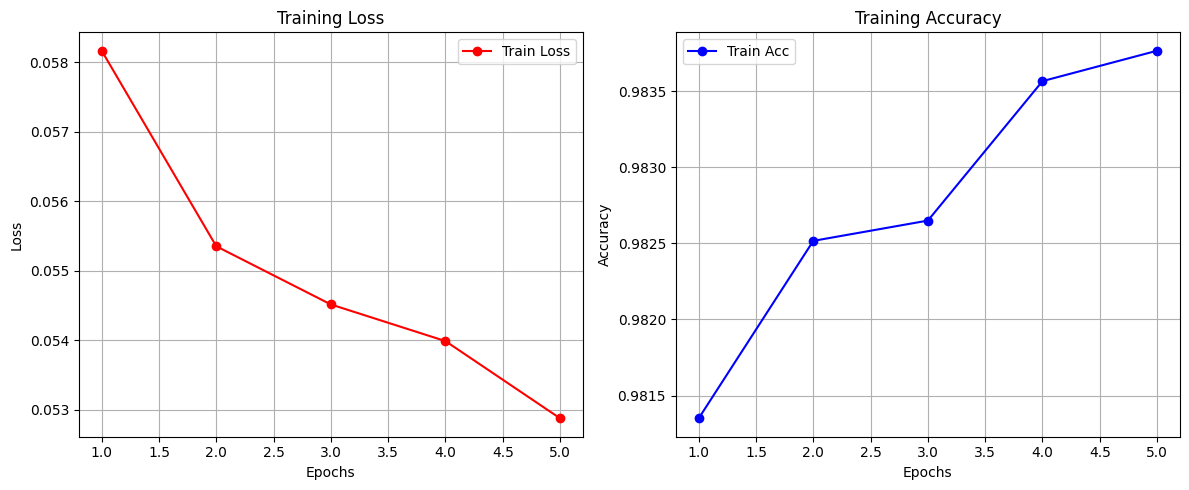

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 5
lr=0.0002
train_LeNet(net, train_iter, test_iter, num_epochs=num_epochs, lr=lr, device=device)